In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign_data.csv to marketing_campaign_data.csv


In [ ]:
#Load Data
import pandas as pd

df = pd.read_csv('marketing_campaign_data.csv')
df.sample(5)

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
324,324,2607,1953,S1,Lajang,40464000.0,0,1,11-01-2013,78,...,8,0,0,0,0,0,0,3,11,0
901,901,8945,1970,S1,Cerai,54137000.0,0,1,16-08-2013,46,...,6,0,0,0,0,0,0,3,11,0
1946,1946,10676,1982,S1,Menikah,63211000.0,0,0,02-11-2012,3,...,2,0,0,0,0,0,0,3,11,1
954,954,8146,1976,S2,Bertunangan,46106000.0,1,1,11-05-2014,84,...,6,0,0,0,0,0,0,3,11,0
1163,1163,6905,1994,S1,Bertunangan,80685000.0,0,0,22-08-2012,55,...,2,0,0,0,0,0,0,3,11,0


In [ ]:
#ambil kolom numerik
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
#Drop Kolom yg tidak perlu
df_numeric = df_numeric.drop(columns=['ID'], errors='ignore')

In [ ]:
#handle missing value
df_numeric = df_numeric.fillna(df_numeric.mean())

In [ ]:
#Scaling Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

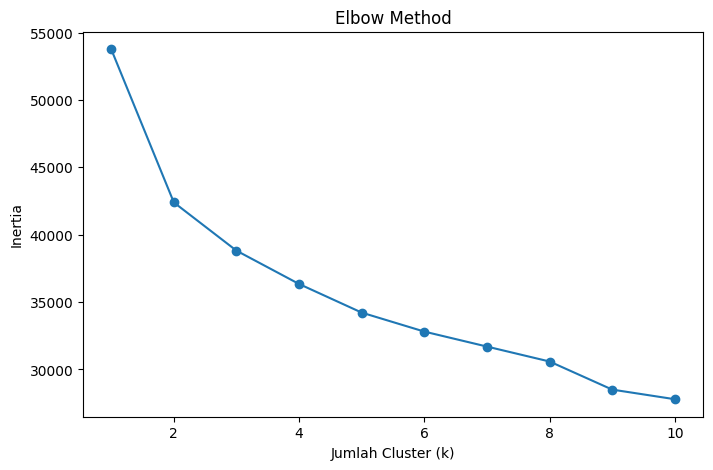

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
#Dari grafik:
k = 1 → 2 → 3 → turunnya masih tajam
k = 3 → 4 → 5 → mulai melandai
setelah k ≥ 4 → penurunannya kecil banget

Titik “siku” paling kelihatan di k = 3

Jadi jumlah cluster optimal adalah k = 3

In [ ]:
#kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_numeric['Cluster'] = clusters

In [ ]:
#silhouette
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.17650495801862406


In [ ]:
#Nilai 0.1765
Cluster kurang terpisah dengan jelas
Banyak data yang masih “deket” antar cluster
Struktur cluster belum optimal

In [ ]:
#Hasil
Hasil evaluasi menggunakan Silhouette Score menunjukkan nilai sebesar 0.176, yang mengindikasikan bahwa kualitas clustering masih tergolong kurang baik.
Hal ini menunjukkan bahwa pemisahan antar cluster belum optimal dan masih terdapat kemiripan antar data di cluster yang berbeda.

In [ ]:
#Kesimpulan
Meskipun berdasarkan Elbow Method jumlah cluster optimal adalah 3, hasil evaluasi menggunakan Silhouette Score menunjukkan bahwa performa model clustering masih kurang baik.
Hal ini dapat disebabkan oleh karakteristik data yang belum memiliki pemisahan yang jelas antar kelompok atau masih adanya fitur yang kurang relevan.

In [ ]:
#Insight :
Untuk meningkatkan kualitas clustering, dapat dilakukan beberapa perbaikan seperti:
1. Melakukan feature selection untuk memilih fitur yang paling relevan
2. Menggunakan teknik dimensionality reduction seperti PCA
3. Mencoba jumlah cluster yang berbeda
4. Menggunakan algoritma clustering lain seperti Hierarchical Clustering atau DBSCAN

In [ ]:
###CLUSTER ANALYSIS, EDA & BUSINESS INSIGHT

In [ ]:
# Menambahkan label cluster ke dataset
df['Cluster'] = clusters

In [ ]:
# Melihat rata-rata tiap fitur berdasarkan cluster
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntCoke,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1112.428844,5632.127985,1971.581662,3.492114e+07,0.805158,0.446991,49.519580,43276.026743,4949.379179,23739.255014,...,6.487106,0.073543,0.007641,0.000000,0.000955,0.001910,0.012416,3.0,11.0,0.094556
1,1136.618012,5432.312112,1964.423913,5.847964e+07,0.201863,0.911491,47.964286,462242.236025,24765.527950,140541.925466,...,5.599379,0.063665,0.135093,0.013975,0.029503,0.013975,0.009317,3.0,11.0,0.107143
2,1112.905282,5703.444444,1968.652095,7.787794e+07,0.040073,0.143898,49.670310,615340.619308,68826.958106,471045.537341,...,2.752277,0.081967,0.131148,0.280510,0.225865,0.034608,0.003643,3.0,11.0,0.302368


In [ ]:
## Interpretasi Cluster

Berdasarkan hasil clustering:

- Cluster 0: Memiliki karakteristik income rendah (~34.9 juta) dan tingkat spending yang rendah. Namun, cluster ini memiliki jumlah kunjungan web yang paling tinggi.
Hal ini menunjukkan bahwa customer sering melakukan browsing tetapi tidak melakukan pembelian secara signifikan.

- Cluster 1: Memiliki karakteristik income menengah (~58.4 juta) dengan tingkat spending yang juga menengah.
Customer pada cluster ini sudah mulai melakukan pembelian, namun belum maksimal sehingga masih memiliki potensi untuk ditingkatkan.

- Cluster 2: Memiliki karakteristik income tinggi (~77.8 juta) dengan tingkat spending paling tinggi dibanding cluster lainnya.
Cluster ini merupakan high value customers yang memberikan kontribusi revenue terbesar meskipun memiliki jumlah kunjungan web yang lebih rendah.

Hal ini menunjukkan adanya perbedaan perilaku pelanggan di setiap cluster, mulai dari customer dengan aktivitas tinggi namun rendah pembelian, hingga customer dengan nilai transaksi tinggi yang lebih selektif dalam berinteraksi.

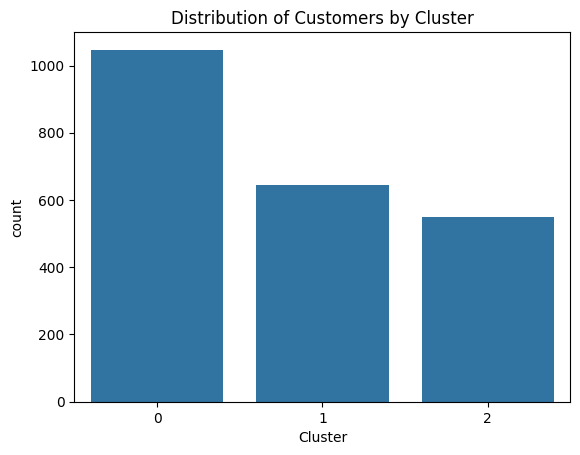

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Cluster', data=df)
plt.title('Distribution of Customers by Cluster')
plt.show()

In [ ]:
## Distribusi Customer per Cluster

Berdasarkan visualisasi, terlihat bahwa jumlah customer terbanyak berada pada Cluster 0, diikuti oleh Cluster 1, dan yang paling sedikit adalah Cluster 2.

Cluster 0 mendominasi jumlah customer, yang menunjukkan bahwa sebagian besar pelanggan berada pada segmen ini. Namun, jumlah yang besar tidak selalu berarti memiliki nilai transaksi yang tinggi.

Cluster 1 memiliki jumlah customer yang cukup signifikan dan berada di posisi menengah, sedangkan Cluster 2 memiliki jumlah paling sedikit namun berpotensi memiliki nilai yang lebih tinggi berdasarkan karakteristik sebelumnya.

Distribusi ini menunjukkan bahwa terdapat perbedaan ukuran segmen pada setiap cluster, yang penting untuk dipertimbangkan dalam strategi marketing.

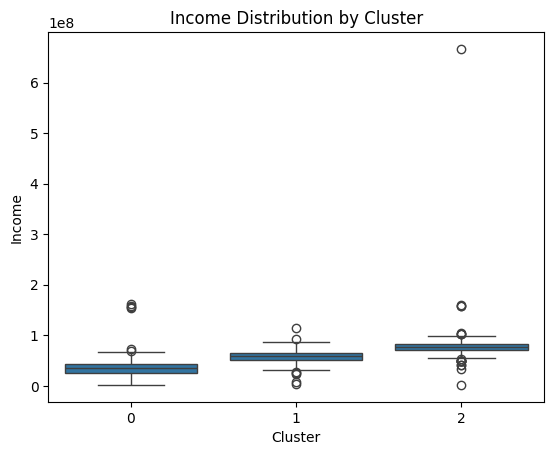

In [ ]:
#INCOME PER CLUSTER
sns.boxplot(x='Cluster', y='Income', data=df)
plt.title('Income Distribution by Cluster')
plt.show()

In [ ]:
## Analisis Income per Cluster

Berdasarkan visualisasi boxplot, terlihat bahwa terdapat perbedaan distribusi income pada setiap cluster.

Cluster 2 memiliki median income tertinggi dibandingkan cluster lainnya, yang menunjukkan bahwa customer pada cluster ini memiliki kemampuan finansial paling tinggi.

Cluster 1 berada pada posisi menengah dengan variasi income yang cukup stabil, sedangkan Cluster 0 memiliki median income terendah.

Selain itu, terdapat beberapa outlier terutama pada Cluster 2, yang menunjukkan adanya customer dengan income sangat tinggi. Hal ini mengindikasikan adanya potensi customer premium dalam cluster tersebut.

Secara keseluruhan, visualisasi ini menunjukkan bahwa segmentasi cluster berhasil memisahkan customer berdasarkan tingkat income.
Perbedaan income ini menjadi dasar dalam menentukan strategi marketing yang berbeda pada setiap cluster.

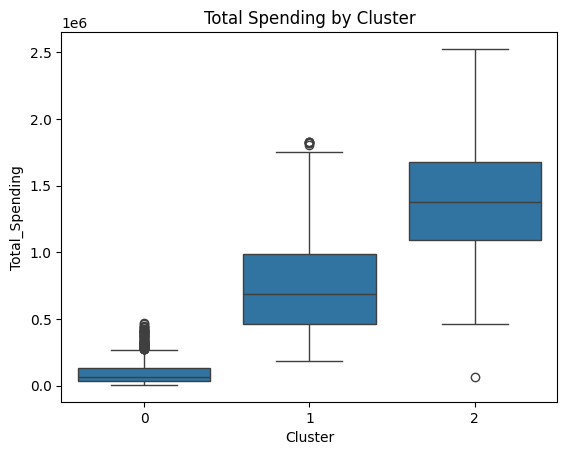

In [ ]:
#Total Spending
spending_cols = ['MntCoke','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']

df['Total_Spending'] = df[spending_cols].sum(axis=1)

sns.boxplot(x='Cluster', y='Total_Spending', data=df)
plt.title('Total Spending by Cluster')
plt.show()

In [ ]:
Cluster 2 memiliki total spending tertinggi, diikuti oleh Cluster 1, dan Cluster 0 terendah.
Hal ini menunjukkan bahwa Cluster 2 merupakan pelanggan dengan kontribusi revenue terbesar.

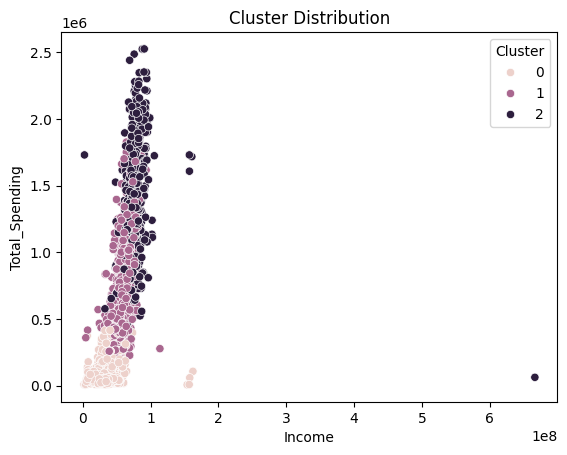

In [ ]:
#Scatterplot
sns.scatterplot(x='Income', y='Total_Spending', hue='Cluster', data=df)
plt.title('Cluster Distribution')
plt.show()

In [ ]:
Scatter plot menunjukkan adanya pemisahan cluster berdasarkan Income dan Total Spending.

Cluster 2 terlihat berada pada area dengan income dan spending tinggi, sehingga dapat dikategorikan sebagai high value customers.

Cluster 1 berada di area tengah, menunjukkan customer dengan nilai menengah yang masih memiliki potensi untuk ditingkatkan.

Cluster 0 berada di area dengan income dan spending rendah, menunjukkan customer dengan kontribusi rendah.

Selain itu, terdapat outlier dengan income sangat tinggi namun spending rendah, yang menunjukkan adanya peluang untuk strategi retargeting.

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,1047
1,644
2,549


In [ ]:
## Pemilihan Target Cluster

Cluster yang dipilih untuk marketing retargetting adalah **Cluster 1**.

Cluster ini memiliki income dan spending menengah serta masih memiliki potensi untuk ditingkatkan melalui strategi marketing yang tepat.

In [ ]:
#Target Cluster
target_cluster = df[df['Cluster'] == 1]

potential_revenue = target_cluster['Income'].sum()

print("Potential Revenue:", potential_revenue)

Potential Revenue: 37193054000.0


In [ ]:
## Potential Impact

Berdasarkan hasil perhitungan, Cluster 1 memiliki potensi revenue sebesar 37.193.054.000

Hal ini menunjukkan bahwa cluster ini memiliki kontribusi finansial yang cukup besar serta peluang untuk ditingkatkan melalui strategi marketing retargeting.

Dengan pendekatan yang tepat, seperti personalized promotion dan upselling, cluster ini berpotensi memberikan peningkatan revenue yang signifikan bagi perusahaan.
Nilai ini menunjukkan bahwa meskipun bukan cluster dengan spending tertinggi, Cluster 1 memiliki peluang besar untuk dioptimalkan.

In [ ]:
#Respon Campaign
df.groupby('Cluster')[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                       'AcceptedCmp4','AcceptedCmp5']].mean()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster,,,,,
0,0.000955,0.001910,0.073543,0.007641,0.000000
1,0.029503,0.013975,0.063665,0.135093,0.013975
2,0.225865,0.034608,0.081967,0.131148,0.280510


In [ ]:
Analisis ini menunjukkan bahwa Cluster 2 memiliki tingkat respons tertinggi terhadap campaign sebelumnya, sehingga dapat dikategorikan sebagai customer yang sudah sangat engaged.

Cluster 1 memiliki tingkat respons yang cukup, namun belum optimal, sehingga memiliki potensi besar untuk ditingkatkan melalui strategi marketing retargeting.

Sementara itu, Cluster 0 memiliki tingkat respons yang sangat rendah, sehingga memerlukan pendekatan awareness dibandingkan retargeting.
Hal ini menunjukkan bahwa strategi marketing sebaiknya difokuskan pada Cluster 1 untuk meningkatkan conversion, serta mempertahankan Cluster 2 sebagai loyal customer.

In [ ]:
## Business Recommendation

Berdasarkan hasil analisis:

- Cluster 1 → Fokus pada retargeting dengan promo personal, upselling, dan digital marketing campaign
- Cluster 2 → Pertahankan dengan loyalty program dan penawaran eksklusif
- Cluster 0 → Tingkatkan awareness dengan promo harga dan edukasi produk

Strategi ini diharapkan dapat meningkatkan conversion rate dan revenue perusahaan.